7 Exercise.

Implement an End to End CNN Model for Image Classification Task.

Objective

In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon
using TensorFlow and Keras.

Task 1: Data Understanding and Visualization:

Download the Provided Data and Complete the following task.
1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.



In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/WEEK5/FruitinAmazon.zip"
extract_path = "dataset"        # folder where it will be extracted

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
extratc_path = "dataset/FruitinAmazon"
train_dir = os.path.join(extratc_path, "train")

# Get class names (folder names)
classes = [folder for folder in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, folder))]

print("Classes:", classes)

Classes: ['guarana', 'pupunha', 'graviola', 'tucuma', 'acai', 'cupuacu']


In [ ]:
import random

image_paths = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)

    random_image = random.choice(images)
    image_paths.append((cls, os.path.join(class_path, random_image)))

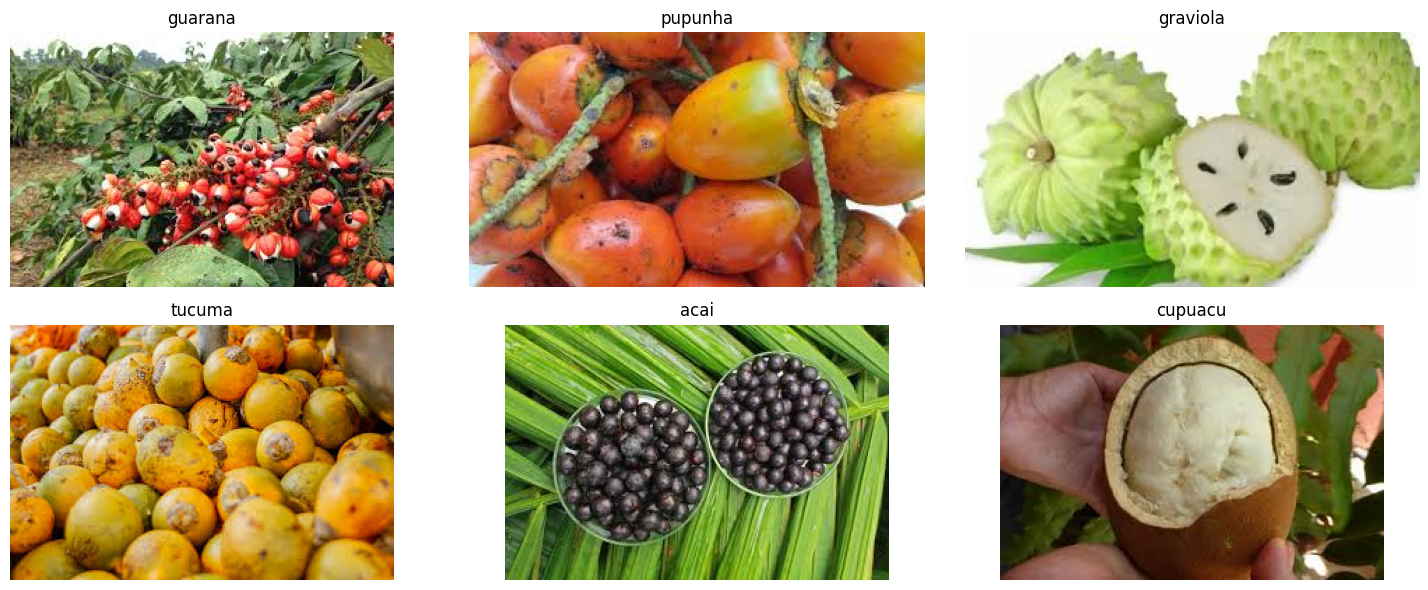

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import math

num_images = len(image_paths)
cols = math.ceil(num_images / 2)

plt.figure(figsize=(15, 6))

for i, (cls, img_path) in enumerate(image_paths):
    plt.subplot(2, cols, i + 1)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

• Hint:

– Iterate through each class subdirectory and check if each image is valid.

– Use the Image.open() function to attempt to load each image.

– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".

– Maintain a list of all corrupted image paths for reporting.

• Expected Output: No corrupted images found.


In [ ]:
corrupted_images= []
for class_name in os.listdir(train_dir):
  class_path = os.path.join(train_dir,class_name)

  if not os.path.isdir(class_path):
        continue

  # Iterate through images in each class
  for img_name in os.listdir(class_path):
      img_path = os.path.join(class_path, img_name)

      try:
          # Try opening and verifying the image
          with Image.open(img_path) as img:
              img.verify()   # verifies image integrity

      except (IOError, SyntaxError):
          print(f"Removed corrupted image: {img_path}")
          corrupted_images.append(img_path)

          # Remove corrupted file
          os.remove(img_path)

# Final report
if len(corrupted_images) == 0:
  print("No Corrupted Images Found.")
else:
  print("\nTotal corrupted images removed:", len(corrupted_images))

No Corrupted Images Found.


Task 2: Loading and Preprocessing Image Data in keras:

In [ ]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Get class names BEFORE applying any map transformations to train_ds
class_names = train_ds.class_names
num_classes = len(class_names)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Number of classes:", num_classes)
print("Class names:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Number of classes: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Task 3 - Implement a CNN with

Follow the following Structure and Hyper - parameters:

Convolutional Architecture:

• Convolutional Layer 1:

– Filter Size (F): (3, 3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 1: Max pooling

– Filter Size (F): (2, 2)

– Stride (s): 2

• Convolutional Layer 2:

– Filter Size (F): (3, 3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1

• Activation Layer: ReLU activation

• Pooling Layer 2: Max pooling

– Filter Size (F): (2, 2)

– Stride (s): 2

Fully Connected Network Architecture:

• Flatten Layer: Flatten the input coming from the convolutional layers

• Input Layer:

• Hidden Layer - 2:

– Number of Neurons: 64

– Number of Neurons: 128

• Output Layer:

– Number of Neurons: num classes (number of output classes)


In [ ]:
from tensorflow.keras import layers, models
model = models.Sequential([
     # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',strides=(1, 1),
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', strides=(1, 1)),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [ ]:
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.1260 - loss: 3.0410
Epoch 1: val_accuracy improved from None to 0.77778, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 539ms/step - accuracy: 0.1250 - loss: 3.0716 - val_accuracy: 0.7778 - val_loss: 1.4113
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.1719 - loss: 1.7527
Epoch 2: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 310ms/step - accuracy: 0.2083 - loss: 1.7285 - val_accuracy: 0.1111 - val_loss: 1.8130
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.1674 - loss: 1.7275
Epoch 3: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 296ms/step - accuracy: 0.2222 - loss: 1.7100 - val_accuracy: 0.3889 - val_loss: 1.7062
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.3181 - loss: 1.6310
Epoch 4: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.3611 - loss: 1.6045 - val_accuracy: 0.6667 - val_loss: 1.3606
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.4542 - loss: 1.399


Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 481ms/step - accuracy: 0.7222 - loss: 0.8223 - val_accuracy: 0.8889 - val_loss: 0.5491
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.7646 - loss: 0.6188
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 712ms/step - accuracy: 0.8333 - loss: 0.5650 - val_accuracy: 0.7222 - val_loss: 1.1705
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9573 - loss: 0.3429
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - accuracy: 0.9583 - loss: 0.3447 - val_accuracy: 0.8889 - val_loss: 0.4428
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.9552 - loss: 0.2486
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 0.9583 - loss: 0.2441 - val_accuracy: 0.8333 - val_loss: 0.8222
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.9799 - loss: 0.

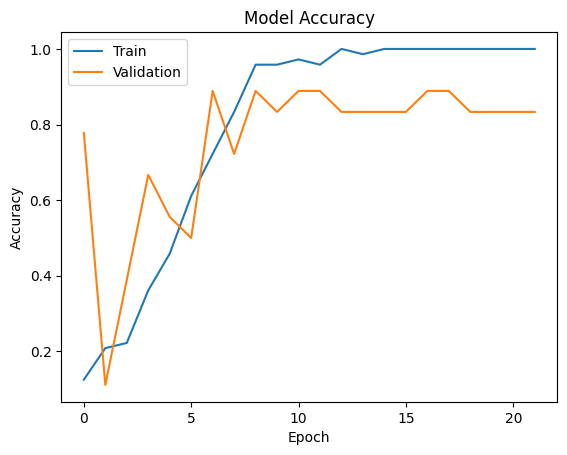

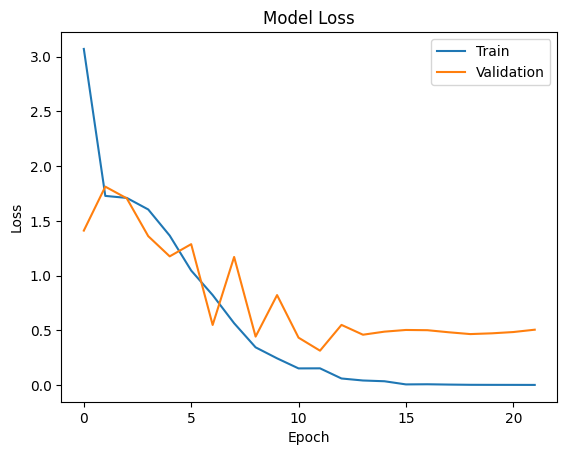

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8889 - loss: 0.3142 
Test Accuracy: 0.8888888955116272
Test Loss: 0.3141617774963379


Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [ ]:
model.save("final_model.h5")
print("Model saved!")

Model saved!


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8889 - loss: 0.3142 
Loaded Model Accuracy: 0.8888888955116272


Task 7: Predictions and Classification Report

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().
• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step


In [ ]:
from sklearn.metrics import classification_report

# class_names was already defined and extracted in an earlier cell (OkWRRjzlawQZ)
# No need to re-extract: class_names = train_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names, labels=range(num_classes)))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       1.00      0.67      0.80         3
      tucuma       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.32      0.27      0.29        18
weighted avg       0.94      0.89      0.91        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me